## LiDAR Terrain Corrections
### This notebook is predominantly derived from the harmonica topographic corrections model

#### Members: Molly Bilhartz, Samantha Lopez, Tessa Murphy

In [3]:
from pathlib import Path
import sys

# Current location:
# Project/NOTEBOOKS/WORKING

PROJECT = Path.cwd().parents[1]

PY_DIR = PROJECT / "notebooks" / "PY files"

GRAVITY_DIR = PROJECT / "data" / "gravity"
LIDAR_DIR = PROJECT / "data" / "LiDAR"

sys.path.append(str(PY_DIR))

import onyx_harmonica_lidar_terrain_correction as tc

# --------------------------------------------------
# INPUT FILES
# --------------------------------------------------

tc.GRAVITY_CSV = GRAVITY_DIR / "Onyx_Gravity_Final_Bouguer_Corrected.csv"

tc.GPS_CSV = GRAVITY_DIR / "raw_data/gps_data/gps_points_with_elevation.csv"

tc.DEM_TILES = [
    LIDAR_DIR / "LiDAR_2026-06-05T15_32_32.740Z/LD26231421.tif",
    LIDAR_DIR / "LiDAR_2026-06-05T15_32_32.740Z/LD26231424.tif",
    LIDAR_DIR / "LiDAR_2026-06-05T15_32_32.740Z/LD26261421.tif",
    LIDAR_DIR / "LiDAR_2026-06-05T15_32_32.740Z/LD26261424.tif",
]

# --------------------------------------------------
# OUTPUT FILES
# --------------------------------------------------

tc.OUT_CSV = GRAVITY_DIR / "Onyx_Gravity_Harmonica_LiDAR_Terrain_Corrected.csv"

tc.OUT_DEM = LIDAR_DIR / "Onyx_Merged_DEM_UTM13N.tif"

# --------------------------------------------------
# MODEL PARAMETERS
# --------------------------------------------------

tc.DST_CRS = "EPSG:26913"

# DEM is in US Survey Feet
tc.DEM_Z_FACTOR = 0.30480060960121924

tc.MODEL_SPACING_M = 5.0
tc.PAD_M = 500.0

# Sandstone-like density
tc.DENSITY_KG_M3 = 2670.0

tc.UPWARD_OFFSET_M = 0.25

In [4]:
gravity = tc.load_and_prepare_gravity()
gravity.head()

,station,gravity_final_mgal,elevation_m,latitude,longitude,free_air_correction_mgal,bouguer_correction_mgal,gravity_tied_mgal,instrument,gps_longitude,gps_latitude,gps_elevation_m
0,1.0,0.589314,2112.468,40.478666,-106.835495,0.803286,0.291414,0.077442,CG5-2,-106.835495,40.478666,2112.468
1,2.0,0.423992,2112.006,40.478675,-106.835498,0.660713,0.239692,0.002971,CG5-2,-106.835498,40.478675,2112.006
2,3.0,0.423230,2111.569,40.478684,-106.835500,0.525854,0.190768,0.088144,CG5-2,-106.835500,40.478684,2111.569
3,4.0,0.458692,2111.692,40.478692,-106.835503,0.563812,0.204538,0.099418,CG5-2,-106.835503,40.478692,2111.692
4,5.0,0.507517,2111.862,40.478702,-106.835504,0.616274,0.223570,0.114813,CG5-2,-106.835504,40.478702,2111.862


In [5]:
topo, gravity_projected = tc.merge_crop_reproject_dem(gravity)

print(topo)
gravity_projected.head()

<xarray.DataArray 'topography' (northing: 46, easting: 132)> Size: 24kB
array([[2053.3691, 2053.3691, 2053.3691, ..., 2050.7024, 2049.5195,
        2048.5513],
       [2145.9497, 2148.3765, 2150.9624, ..., 2049.5828, 2048.5952,
        2047.7897],
       [2145.4502, 2147.958 , 2150.595 , ..., 2048.1746, 2047.3188,
        2046.5831],
       ...,
       [2122.3855, 2121.1804, 2119.9207, ..., 2043.8217, 2043.5624,
        2043.3958],
       [2121.2751, 2119.9026, 2118.7473, ..., 2043.4086, 2043.2509,
        2043.4651],
       [2119.9163, 2118.5005, 2117.2124, ..., 2043.2483, 2043.7255,
        2044.375 ]], dtype=float32)
Coordinates:
  * northing  (northing) float64 368B 4.483e+06 4.483e+06 ... 4.483e+06
  * easting   (easting) float64 1kB 3.439e+05 3.439e+05 ... 3.446e+05 3.446e+05
Attributes:
    units:        m
    crs:          EPSG:26913
    description:  LiDAR DEM reprojected to meters


,station,gravity_final_mgal,elevation_m,latitude,longitude,free_air_correction_mgal,bouguer_correction_mgal,gravity_tied_mgal,instrument,gps_longitude,gps_latitude,gps_elevation_m,easting_m,northing_m
0,1.0,0.589314,2112.468,40.478666,-106.835495,0.803286,0.291414,0.077442,CG5-2,-106.835495,40.478666,2112.468,344418.058854,4.482505e+06
1,2.0,0.423992,2112.006,40.478675,-106.835498,0.660713,0.239692,0.002971,CG5-2,-106.835498,40.478675,2112.006,344417.830475,4.482506e+06
2,3.0,0.423230,2111.569,40.478684,-106.835500,0.525854,0.190768,0.088144,CG5-2,-106.835500,40.478684,2111.569,344417.640938,4.482507e+06
3,4.0,0.458692,2111.692,40.478692,-106.835503,0.563812,0.204538,0.099418,CG5-2,-106.835503,40.478692,2111.692,344417.436458,4.482508e+06
4,5.0,0.507517,2111.862,40.478702,-106.835504,0.616274,0.223570,0.114813,CG5-2,-106.835504,40.478702,2111.862,344417.349965,4.482509e+06


In [6]:
out = tc.compute_harmonica_terrain_correction(gravity_projected, topo)
out.head()

,station,gravity_final_mgal,elevation_m,latitude,longitude,free_air_correction_mgal,bouguer_correction_mgal,gravity_tied_mgal,instrument,gps_longitude,gps_latitude,gps_elevation_m,easting_m,northing_m,dem_elevation_m_at_station,obs_height_used_m,harmonica_topography_effect_mgal,gravity_harmonica_lidar_corrected_mgal,harmonica_minus_simple_bouguer_mgal,simple_bouguer_minus_harmonica_effect_mgal
0,1.0,0.589314,2112.468,40.478666,-106.835495,0.803286,0.291414,0.077442,CG5-2,-106.835495,40.478666,2112.468,344418.058854,4.482505e+06,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,0.423992,2112.006,40.478675,-106.835498,0.660713,0.239692,0.002971,CG5-2,-106.835498,40.478675,2112.006,344417.830475,4.482506e+06,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,0.423230,2111.569,40.478684,-106.835500,0.525854,0.190768,0.088144,CG5-2,-106.835500,40.478684,2111.569,344417.640938,4.482507e+06,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,0.458692,2111.692,40.478692,-106.835503,0.563812,0.204538,0.099418,CG5-2,-106.835503,40.478692,2111.692,344417.436458,4.482508e+06,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,0.507517,2111.862,40.478702,-106.835504,0.616274,0.223570,0.114813,CG5-2,-106.835504,40.478702,2111.862,344417.349965,4.482509e+06,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# out.to_csv(tc.OUT_CSV, index=False)
# print("Saved:", tc.OUT_CSV)

Saved: /Users/tessamurphy/work/classes/GPGN486/Geophysical-Characterization-of-the-Historic-Onyx-Mine-in-Steamboat-Springs-CO.-/data/gravity/Onyx_Gravity_Harmonica_LiDAR_Terrain_Corrected.csv


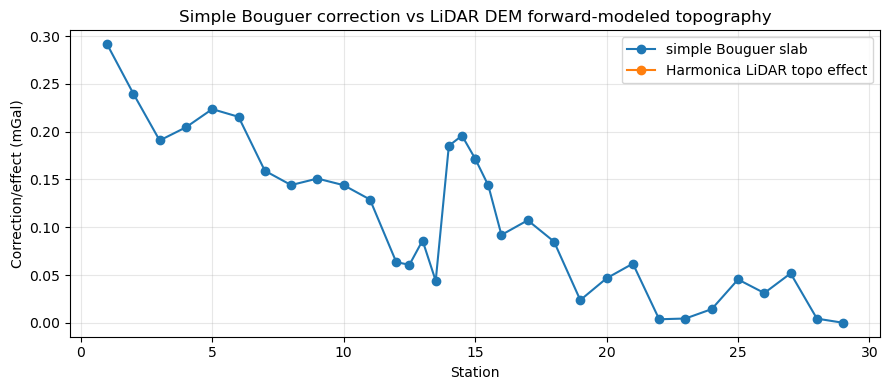

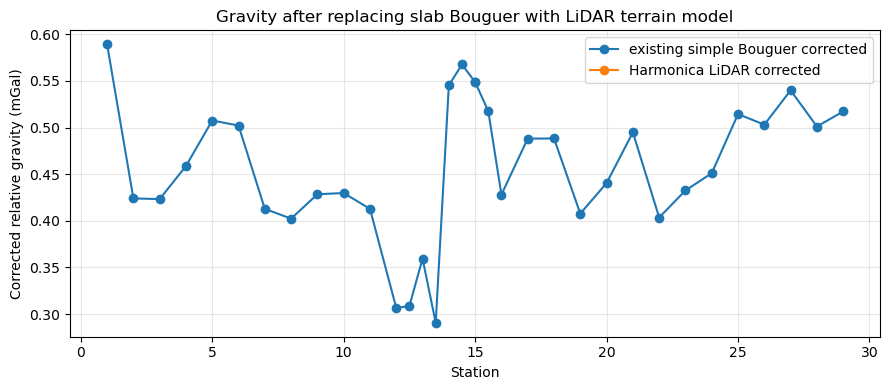

In [8]:
tc.plot_qc(out)

## Got NANS for LiDAR corrected vlues, must recompute and do checks. 

In [9]:
print(out.columns.tolist())

cols = [
    "station",
    "bouguer_correction_mgal",
    "harmonica_topography_effect_mgal",
    "gravity_harmonica_lidar_corrected_mgal",
]

out[cols].head(30)

['station', 'gravity_final_mgal', 'elevation_m', 'latitude', 'longitude', 'free_air_correction_mgal', 'bouguer_correction_mgal', 'gravity_tied_mgal', 'instrument', 'gps_longitude', 'gps_latitude', 'gps_elevation_m', 'easting_m', 'northing_m', 'dem_elevation_m_at_station', 'obs_height_used_m', 'harmonica_topography_effect_mgal', 'gravity_harmonica_lidar_corrected_mgal', 'harmonica_minus_simple_bouguer_mgal', 'simple_bouguer_minus_harmonica_effect_mgal']


,station,bouguer_correction_mgal,harmonica_topography_effect_mgal,gravity_harmonica_lidar_corrected_mgal
0,1.0,0.291414,NaN,NaN
1,2.0,0.239692,NaN,NaN
2,3.0,0.190768,NaN,NaN
3,4.0,0.204538,NaN,NaN
4,5.0,0.223570,NaN,NaN
5,6.0,0.215510,NaN,NaN
6,7.0,0.159085,NaN,NaN
7,8.0,0.144084,NaN,NaN
8,9.0,0.150913,NaN,NaN
9,10.0,0.143972,NaN,NaN


In [10]:
print("Gravity projected coordinate range:")
print("Easting:", gravity_projected["easting_m"].min(), gravity_projected["easting_m"].max())
print("Northing:", gravity_projected["northing_m"].min(), gravity_projected["northing_m"].max())

print("\nTopo coordinate range:")
print("Easting:", float(topo.easting.min()), float(topo.easting.max()))
print("Northing:", float(topo.northing.min()), float(topo.northing.max()))

print("\nDEM elevation at stations:")
print(out[["station", "dem_elevation_m_at_station", "obs_height_used_m"]].head(30))

Gravity projected coordinate range:
Easting: 344413.82448802976 344418.05885412626
Northing: 4482504.652252167 4482531.999133004

Topo coordinate range:
Easting: 343916.32448802976 344571.32448802976
Northing: 4482804.499133004 4483029.499133004

DEM elevation at stations:
    station  dem_elevation_m_at_station  obs_height_used_m
0       1.0                         NaN                NaN
1       2.0                         NaN                NaN
2       3.0                         NaN                NaN
3       4.0                         NaN                NaN
4       5.0                         NaN                NaN
5       6.0                         NaN                NaN
6       7.0                         NaN                NaN
7       8.0                         NaN                NaN
8       9.0                         NaN                NaN
9      10.0                         NaN                NaN
10     11.0                         NaN                NaN
11     12.0       

In [11]:
inside_x = (
    (gravity_projected["easting_m"] >= float(topo.easting.min())) &
    (gravity_projected["easting_m"] <= float(topo.easting.max()))
)

inside_y = (
    (gravity_projected["northing_m"] >= float(topo.northing.min())) &
    (gravity_projected["northing_m"] <= float(topo.northing.max()))
)

print("Stations inside DEM x-range:", inside_x.sum(), "/", len(gravity_projected))
print("Stations inside DEM y-range:", inside_y.sum(), "/", len(gravity_projected))
print("Stations inside both:", (inside_x & inside_y).sum(), "/", len(gravity_projected))

Stations inside DEM x-range: 34 / 34
Stations inside DEM y-range: 0 / 34
Stations inside both: 0 / 34


In [12]:
import rasterio

for f in tc.DEM_TILES:
    with rasterio.open(f) as src:
        print("\n", f.name)
        print("CRS:", src.crs)
        print("Bounds:", src.bounds)


 LD26231421.tif
CRS: EPSG:6430
Bounds: BoundingBox(left=2623000.0, bottom=1421000.0, right=2626000.0, top=1424000.0)

 LD26231424.tif
CRS: EPSG:6430
Bounds: BoundingBox(left=2623000.0, bottom=1424000.0, right=2626000.0, top=1427000.0)

 LD26261421.tif
CRS: EPSG:6430
Bounds: BoundingBox(left=2626000.0, bottom=1421000.0, right=2629000.0, top=1424000.0)

 LD26261424.tif
CRS: EPSG:6430
Bounds: BoundingBox(left=2626000.0, bottom=1424000.0, right=2629000.0, top=1427000.0)
